# Imports

In [1]:
import torch
from datetime import datetime
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import sys
sys.path.append('../')
from src.utils.data_preprocessing import DataPreprocessor
from src.utils.model_training import ModelTrainer
from src.models.vgg16_1D import VGG16_1D

# Variables

In [2]:
SAMPLING_FREQUENCY = 100
TASK = "superdiagnostic"
CLASS_NAMES = ['MI', 'NORM'] # OTHER

DATA_DIR = "../data/raw/ptb_xl_ecg/"

PREPROCESSED_DIR = f"../data/preprocessed/"
SINGLE_BEATS_DIR = PREPROCESSED_DIR + "single_beats/"
IG_DIR = PREPROCESSED_DIR + "integrated_gradients/"

SCALER_DIR = f"../data/results/scaler/"

date_today = datetime.now().strftime("%Y_%m_%d")
MODEL_PATH = f"../src/models/trained/"              # + vgg16_1d_trained_{date_today}_epochs{epochs_to_train}.pth
HISTORY_PATH = f"../data/results/training_history/" # + training_history_{date_today}.csv
CHECKPOINT_PATH = f'../src/models/checkpoints/'     # + checkpoint_{date_today}_epochs{epochs_to_train}.pth

# ECG-Ableitungsnamen (Standard 12-Lead ECG)
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Load Data

In [3]:
X_train, y_train = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "train")
X_val, y_val = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "val")
X_test, y_test = DataPreprocessor.load_processed_data(PREPROCESSED_DIR, "test")

Loading processed data from ../data/preprocessed/ with prefix train
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test


In [4]:
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for split_name, y_split in splits.items():
    y_arr = np.asarray(y_split)
    # Multi-Label: Summiere pro Klasse (Spalte)
    if y_arr.ndim == 2 and y_arr.shape[1] == len(CLASS_NAMES):
        counts = y_arr.sum(axis=0)
    else:
        counts = np.bincount(y_arr, minlength=len(CLASS_NAMES))
    perc = counts / counts.sum() * 100
    print(f"{split_name}:")
    for name, c, p in zip(CLASS_NAMES, counts, perc):
        print(f"  {name}: {int(c)} ({p:.2f}%)")
    print(f"  TOTAL: {int(counts.sum())} (100.00%)\n")

Train:
  MI: 52957 (38.06%)
  NORM: 86180 (61.94%)
  TOTAL: 139137 (100.00%)

Validation:
  MI: 6596 (37.87%)
  NORM: 10820 (62.13%)
  TOTAL: 17416 (100.00%)

Test:
  MI: 6769 (38.38%)
  NORM: 10869 (61.62%)
  TOTAL: 17638 (100.00%)



In [5]:
# [Batch_Size, Channels, Sequence_Length] 
X_test.shape

(17638, 12, 70)

# Load Model

In [6]:
# Initialize for loading existing model
model = VGG16_1D(in_channels=12, num_classes=len(CLASS_NAMES), input_length=70)
optimizer = optim.Adam(model.parameters(), lr=0.00001)
criterion = ModelTrainer.create_weighted_criterion(y_train, weight_factor=0.5)
epochs_to_train = 30

trainer = ModelTrainer(model, None, None, None, optimizer, criterion)

In [7]:
date = "2025_09_26"
spec = ""
model_name = f"vgg16_1d_trained_{date}_epochs{epochs_to_train}.pth"
checkpoint_name = f"checkpoint_{date}_epochs{epochs_to_train}.pth"
history_name = f"training_history_{date}.csv"

# load existing model
trainer.load_model(MODEL_PATH + model_name)
trainer.load_training_history(CLASS_NAMES, HISTORY_PATH + history_name)

Modell erfolgreich aus '../src/models/trained/vgg16_1d_trained_2025_09_26_epochs30.pth' geladen.
Trainingshistorie erfolgreich aus '../data/results/training_history/training_history_2025_09_26.csv' geladen.


c:\Users\AliceKitchkin\Repos\ECG_xAI\notebooks\..\src\utils\model_training.py:469: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(path, 

In [8]:
print("model.flattened_size:", model.flattened_size)
print("classifier[0].in_features:", model.classifier[0].in_features)
print("classifier[0].weight.shape:", model.classifier[0].weight.shape)

model.flattened_size: 2048
classifier[0].in_features: 2048
classifier[0].weight.shape: torch.Size([256, 2048])


# Integrated Gradients

In [10]:
model.eval()

VGG16_1D(
  (features): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv1d(128, 256, kernel_size=(3,)

In [11]:
def grab_samples(y_test, target_label_name, sample_size=5):
    # Target-Index finden
    target_idx = CLASS_NAMES.index(target_label_name)
    
    # Alle Samples mit dem gewünschten Label finden
    y_test_array = np.array(y_test)
    if y_test_array.ndim == 2:  # Multi-label format
        sample_indices = np.where(y_test_array[:, target_idx] == 1)[0]
    else:  # Single-label format
        sample_indices = np.where(y_test_array == target_idx)[0]
    
    sample_size_max = len(sample_indices)
    sample_size = sample_size_max if sample_size > sample_size_max else sample_size
    
    # maximal bis sample_size, für schnellere Berechnung, zufällig auswählen
    if sample_size_max > sample_size:
        sample_indices = np.random.choice(sample_indices, size=sample_size, replace=False)
    # else: take all samples

    print(f"Zufällig verarbeitete {target_label_name}-Samples: {len(sample_indices)} von {sample_size_max} (max)")
    return sample_indices, target_idx

In [12]:
from tqdm import tqdm
def compute_integrated_gradients_for_label(model, X_test, sample_indices, target_idx):
    ig = IntegratedGradients(model)

    # Attributionen für alle gefundenen Samples berechnen
    all_attributions = []
    convergence_deltas = []

    for i, sample_idx in enumerate(tqdm(sample_indices, desc=f"Computing attributions for target {target_idx}")):
        # Input-Daten vorbereiten
        sample_data = torch.tensor(X_test[sample_idx:sample_idx+1]).float()
        
        # Baseline (Nullvektor)
        baseline = torch.zeros_like(sample_data)
        
        # Attribution berechnen (für die Target-Klasse)
        attribution, convergence_delta = ig.attribute(
            sample_data, target=target_idx, baselines=baseline, 
            method='gausslegendre', return_convergence_delta=True
            )
        
        # Speichern
        all_attributions.append(attribution.numpy())
        convergence_deltas.append(convergence_delta.item())
        
    return all_attributions, convergence_deltas

In [65]:
sample_size_to_observe = 11000

## Label: NORM

In [66]:
sample_indices_NORM, target_idx_NORM = grab_samples(y_test, "NORM", sample_size_to_observe)
attributions_NORM, convergence_deltas_NORM = compute_integrated_gradients_for_label(model, X_test, sample_indices_NORM, target_idx_NORM)

Zufällig verarbeitete NORM-Samples: 10869 von 10869 (max)


Computing attributions for target 1: 100%|██████████| 10869/10869 [12:57<00:00, 13.99it/s]


In [67]:
def save_attributions(attributions, indices, deltas, filename_prefix):
    with open(IG_DIR + f"{filename_prefix}_attributions.pkl", "wb") as f:
        pickle.dump(attributions, f)
    with open(IG_DIR + f"{filename_prefix}_indices.pkl", "wb") as f:
        pickle.dump(indices, f)
    with open(IG_DIR + f"{filename_prefix}_deltas.pkl", "wb") as f:
        pickle.dump(deltas, f)
save_attributions(attributions_NORM, sample_indices_NORM, convergence_deltas_NORM, "NORM")

In [68]:
def load_attributions(filename_prefix):
    with open(IG_DIR + f"{filename_prefix}_attributions.pkl", "rb") as f:
        attributions = pickle.load(f)
    with open(IG_DIR + f"{filename_prefix}_indices.pkl", "rb") as f:
        indices = pickle.load(f)
    with open(IG_DIR + f"{filename_prefix}_deltas.pkl", "rb") as f:
        deltas = pickle.load(f)
    return attributions, indices, deltas
attributions_NORM, sample_indices_NORM, convergence_deltas_NORM = load_attributions("NORM")

Convergence Delta: [0.34873294830322266, -0.23214101791381836, 0.7619113922119141, 0.4203033447265625, 0.05083274841308594, -0.31372785568237305, 0.47327566146850586, -0.15832090377807617, 0.10323333740234375, 0.6137776374816895, -0.010629653930664062, -0.0681600570678711, -0.6022281646728516, -0.13975906372070312, 0.7522706985473633, -0.015746116638183594, -0.026506423950195312, -0.32000732421875, -0.07712078094482422, -0.24874639511108398, -0.018771648406982422, 0.22520923614501953, -0.39817142486572266, -0.09798002243041992, 0.17981624603271484, -0.08620357513427734, 0.28742170333862305, 0.7995264530181885, -0.3325028419494629, -0.3027496337890625, -0.35242223739624023, 0.8291759490966797, 0.05480945110321045, -0.5959630012512207, -0.40633583068847656, 0.2649359703063965, 0.2028369903564453, 0.321993350982666, 0.11729907989501953, 0.7997770309448242, -0.06382179260253906, -0.037489891052246094, 0.044426918029785156, 0.8499679565429688, -0.23340415954589844, -0.8731698989868164, 0.12

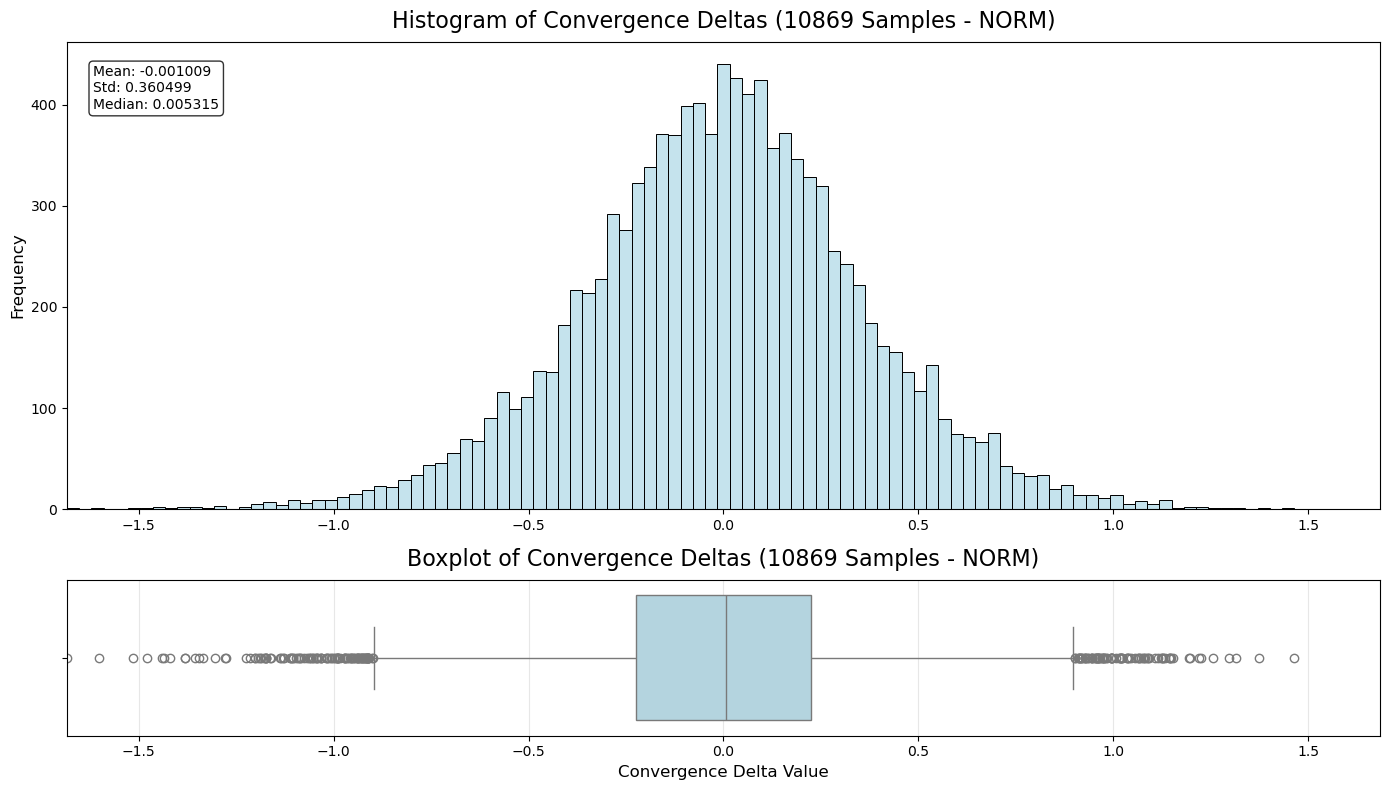

In [69]:
# convergence_delta ist ein Wert, der misst, wie gut die Integrated Gradients die Completeness-Eigenschaft erfüllen:
# Die Summe der Attributionen sollte möglichst genau der Differenz zwischen Modell-Output für das echte Sample und
# die Baseline entsprechen (f(x) - f(baseline)).

# Typische Anwendungen:
# Qualitätskontrolle: Ein kleiner Wert zeigt, dass die Attributionen zuverlässig sind. Ein großer Wert kann auf Probleme
#   (z.B. Modellinstabilität, ungeeignete Baseline) hinweisen.
# Debugging: Du kannst convergence_delta für jedes Sample ausgeben, plotten oder als Filter verwenden (z.B. nur Attributionen
#   mit kleinem delta weiter analysieren).

# Kleine Werte (nahe 0): Die Attributionen sind zuverlässig und erfüllen die Completeness-Eigenschaft gut
# Große Werte: Die Attributionen sind weniger zuverlässig. Mögliche Ursachen: Modellinstabilität, ungeeignete Baseline, numerische Probleme

print("Convergence Delta:", convergence_deltas_NORM)

def plot_convergence_delta_hist_and_box(convergence_deltas, label):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    ax_hist = axes[0]
    sns.histplot(convergence_deltas, bins=100, alpha=0.7, ax=ax_hist, color='lightblue')

    max_abs_value = max(abs(np.min(convergence_deltas)), abs(np.max(convergence_deltas)))
    ax_hist.set_xlim(-max_abs_value, max_abs_value)

    title_hist = f"Histogram of Convergence Deltas ({len(convergence_deltas)} Samples - {label})"
    title_box = f"Boxplot of Convergence Deltas ({len(convergence_deltas)} Samples - {label})"
    ax_hist.set_title(title_hist, fontsize=16, pad=10)
    ax_hist.set_ylabel('Frequency', fontsize=12)
    ax_hist.tick_params(axis='x', labelbottom=True)

    stats_text = f'Mean: {np.mean(convergence_deltas):.6f}\nStd: {np.std(convergence_deltas):.6f}\nMedian: {np.median(convergence_deltas):.6f}'
    ax_hist.text(0.02, 0.95, stats_text, transform=ax_hist.transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Boxplot
    ax_box = axes[1]
    sns.boxplot(x=convergence_deltas, color='lightblue', ax=ax_box)
    ax_box.set_title(title_box, fontsize=16, pad=10)
    ax_box.set_xlabel('Convergence Delta Value', fontsize=12)
    ax_box.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_convergence_delta_hist_and_box(convergence_deltas_NORM, "NORM")

In [70]:
def attribution_statistics(attributions):
    # Attribution-Verteilungsanalyse
    attr_flat = np.concatenate([attr.flatten() for attr in attributions])

    print("=== ATTRIBUTION ANALYSIS ===")
    print(f"Samples: {len(attributions)}")
    print(f"Total attribution values per sample: {len(attr_flat)} (Samples*Leads*Sequence Length)")
    print(f"Min: {np.min(attr_flat):.6f} (less influence)")
    print(f"Max: {np.max(attr_flat):.6f} (most influence)")
    print(f"Mean: {np.mean(attr_flat):.6f}")
    print(f"Std: {np.std(attr_flat):.6f}")
    print()

    # Percentage Distribution
    threshold_low = 0.1
    threshold_high = -0.1
    neutral = np.sum((attr_flat >= threshold_high) & (attr_flat <= threshold_low))
    positive = np.sum(attr_flat > threshold_low)
    negative = np.sum(attr_flat < threshold_high)

    print("Proportion of values that have almost no, positive, or negative \ninfluence on the decision for the target class.")
    print(f"Neutral (-0.1 < x < 0.1): {neutral} ({neutral/len(attr_flat)*100:.1f}%)")
    print(f"Positive (x > 0.1): {positive} ({positive/len(attr_flat)*100:.1f}%)")
    print(f"Negative (x < -0.1): {negative} ({negative/len(attr_flat)*100:.1f}%)")

    return attr_flat

attr_flat_NORM = attribution_statistics(attributions_NORM)

=== ATTRIBUTION ANALYSIS ===
Samples: 10869
Total attribution values per sample: 9129960 (Samples*Leads*Sequence Length)
Min: -13.831864 (less influence)
Max: 12.600624 (most influence)
Mean: 0.007817
Std: 0.304836

Proportion of values that have almost no, positive, or negative 
influence on the decision for the target class.
Neutral (-0.1 < x < 0.1): 7098636 (77.8%)
Positive (x > 0.1): 1084069 (11.9%)
Negative (x < -0.1): 947255 (10.4%)


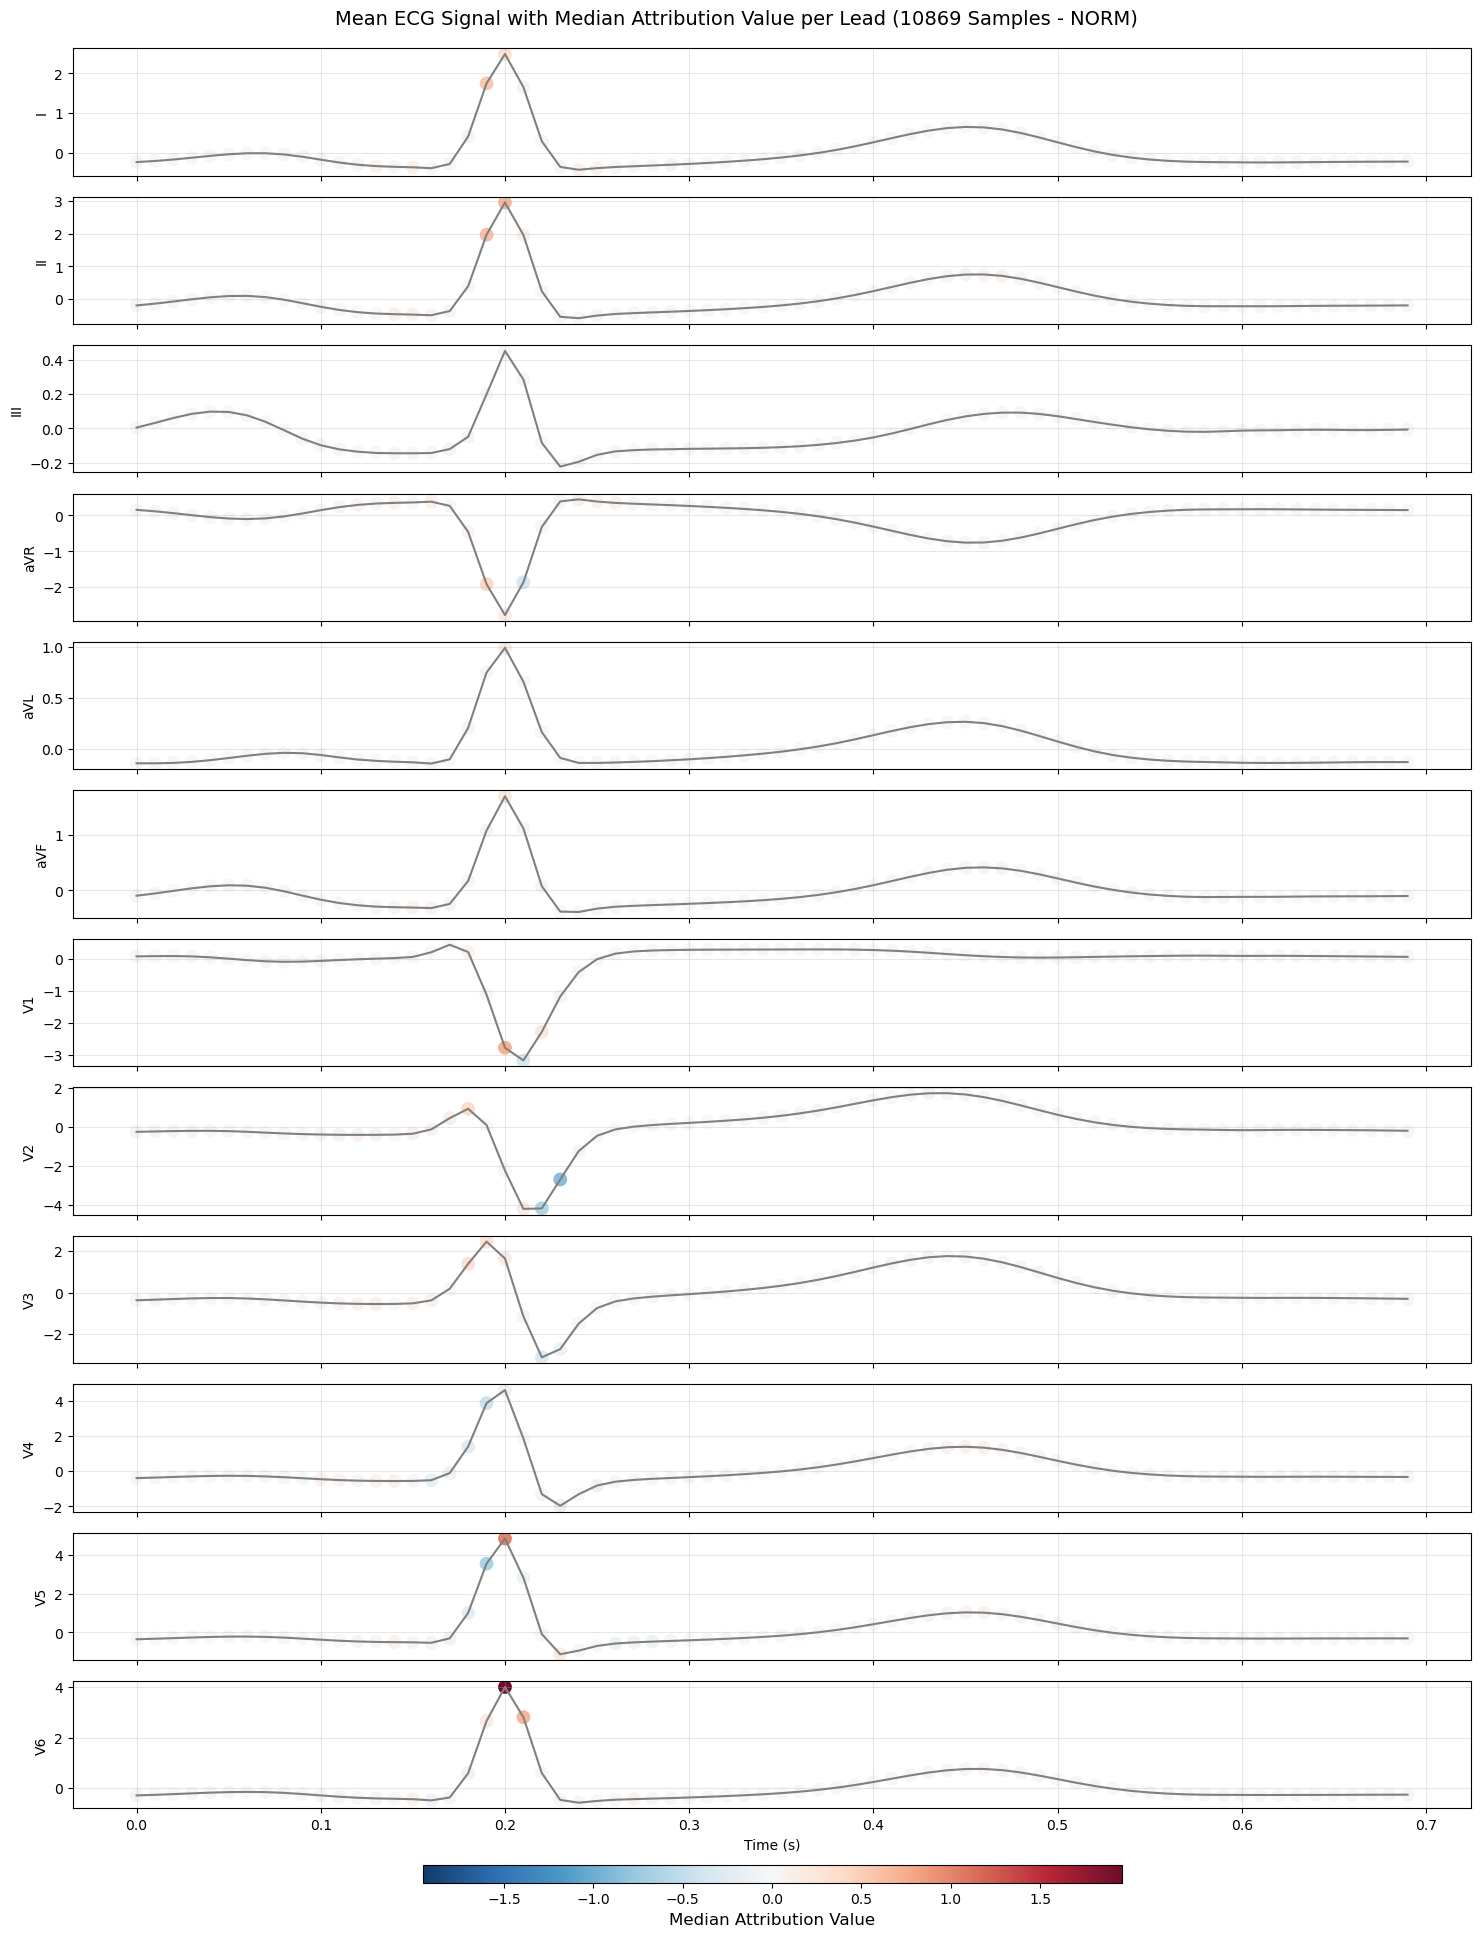

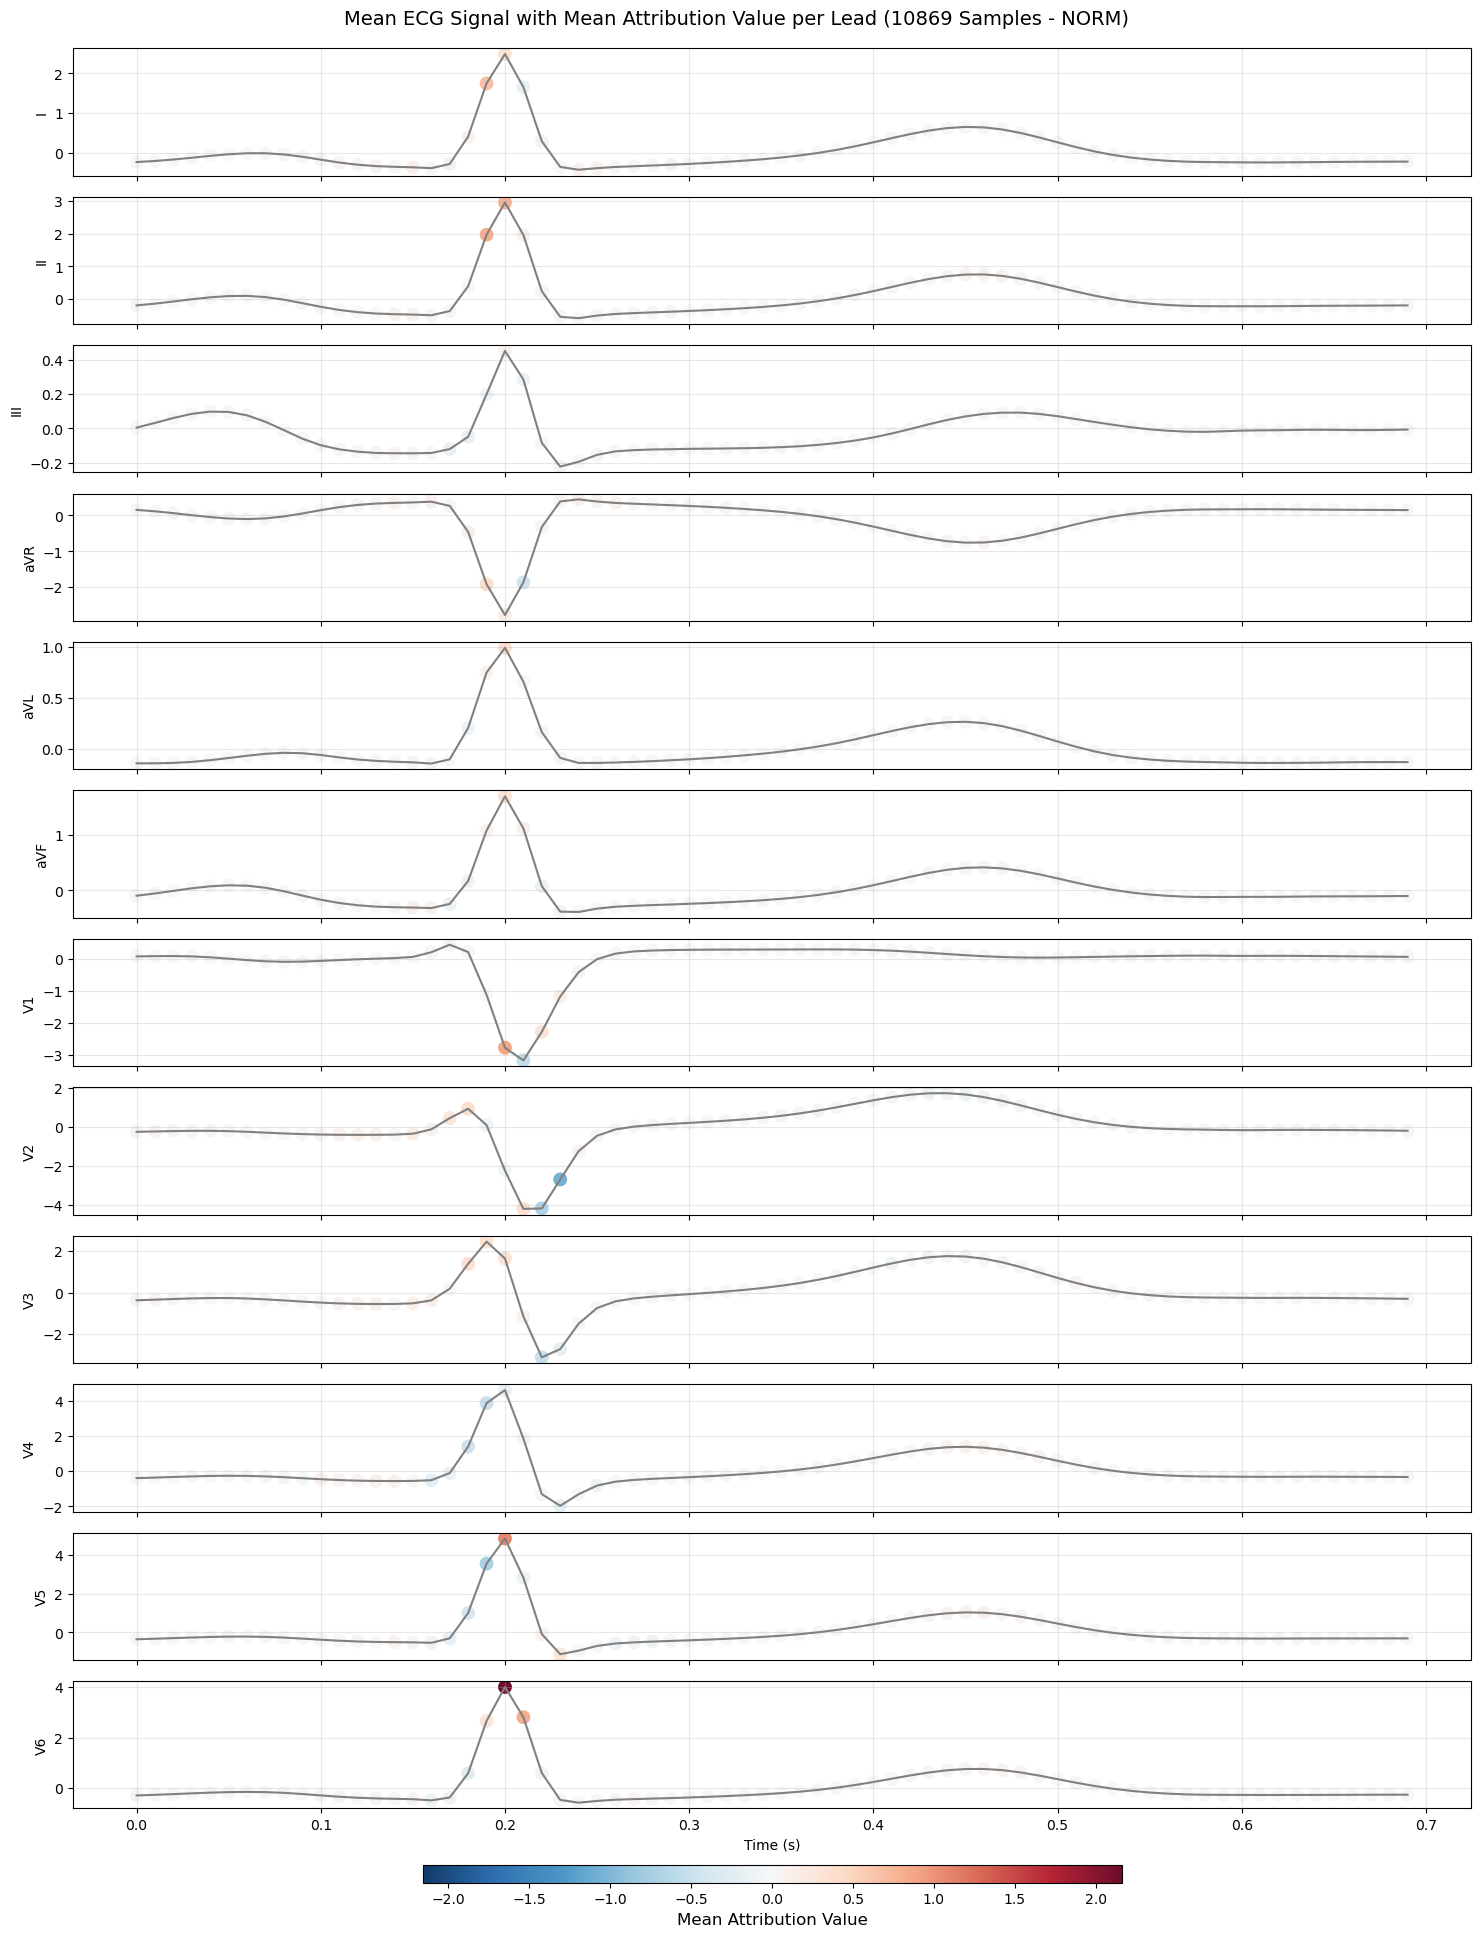

In [71]:
def mean_attribution_per_lead_time(attributions, lead_names):
    "Wie wichtig war dieser Zeitpunkt in dieser Ableitung im Durchschnitt für die Modellentscheidung (für die Klasse NORM)?"
    # Attributionen zu [samples, time, leads] bringen
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]
    mean_attr = np.mean(attr_arr, axis=0)  # [time, leads]
    return mean_attr

def median_attribution_per_lead_time(attributions, lead_names):
    """
    Berechnet den Median der Attributionen je Zeitpunkt und je Ableitung über alle Samples.
    Ergebnis: [time, leads]
    """
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]
    median_attr = np.median(attr_arr, axis=0)  # [time, leads]
    return median_attr

def mean_signal_per_lead_time(X, sample_indices, lead_names):
    # Hole die entsprechenden EKG-Signale
    signals = []
    for idx in sample_indices:
        signal = X[idx]
        if signal.shape[0] == len(lead_names):
            signal = signal.T  # [time, leads]
        signals.append(signal)
    signals = np.array(signals)  # [samples, time, leads]
    mean_signal = np.mean(signals, axis=0)  # [time, leads]
    return mean_signal

def plot_ecg_attributions_summary(attributions, X, sample_indices, lead_names, sampling_frequency=100, method='mean', class_name="X"):
    """
    Plottet die mittleren oder medianen Attributionen pro Zeitpunkt und Lead.
    method: 'mean' oder 'median'
    """
    # Signalmittelwert
    mean_signal = mean_signal_per_lead_time(X, sample_indices, lead_names)
    
    # Attributionen aggregieren
    if method == 'mean':
        attr = mean_attribution_per_lead_time(attributions, lead_names)
        label = 'Mean Attribution Value'
    elif method == 'median':
        attr = median_attribution_per_lead_time(attributions, lead_names)
        label = 'Median Attribution Value'
    else:
        raise ValueError("method must be 'mean' or 'median'")
    
    # Symmetrische Farbskala um 0
    vmin = -max(abs(attr.min()), abs(attr.max()))
    vmax = max(abs(attr.min()), abs(attr.max()))
    
    # Plot
    fig, axes = plt.subplots(len(lead_names), 1, figsize=(15, 20), sharex=True)
    fig.suptitle(f"Mean ECG Signal with {label} per Lead ({len(sample_indices)} Samples - {class_name})", fontsize=14, y=0.995)
    time_axis = np.arange(mean_signal.shape[0]) / sampling_frequency

    scatters = []
    for i in range(len(lead_names)):
        axes[i].plot(time_axis, mean_signal[:, i], color='grey', label='Mean ECG')
        scatter = axes[i].scatter(
            time_axis, mean_signal[:, i], c=attr[:, i],
            cmap="RdBu_r", s=80, alpha=0.95, vmin=vmin, vmax=vmax
        )
        scatters.append(scatter)
        axes[i].set_ylabel(lead_names[i])
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    cbar = fig.colorbar(scatters[0], ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, aspect=40, shrink=0.5)
    cbar.set_label(f'{label}', fontsize=12)
    cbar.ax.xaxis.set_label_position('bottom')
    plt.show()

plot_ecg_attributions_summary(
    attributions_NORM, X_test, sample_indices_NORM, lead_names,
    SAMPLING_FREQUENCY, 'median', "NORM")

plot_ecg_attributions_summary(
    attributions_NORM, X_test, sample_indices_NORM, lead_names,
    SAMPLING_FREQUENCY, 'mean', "NORM")

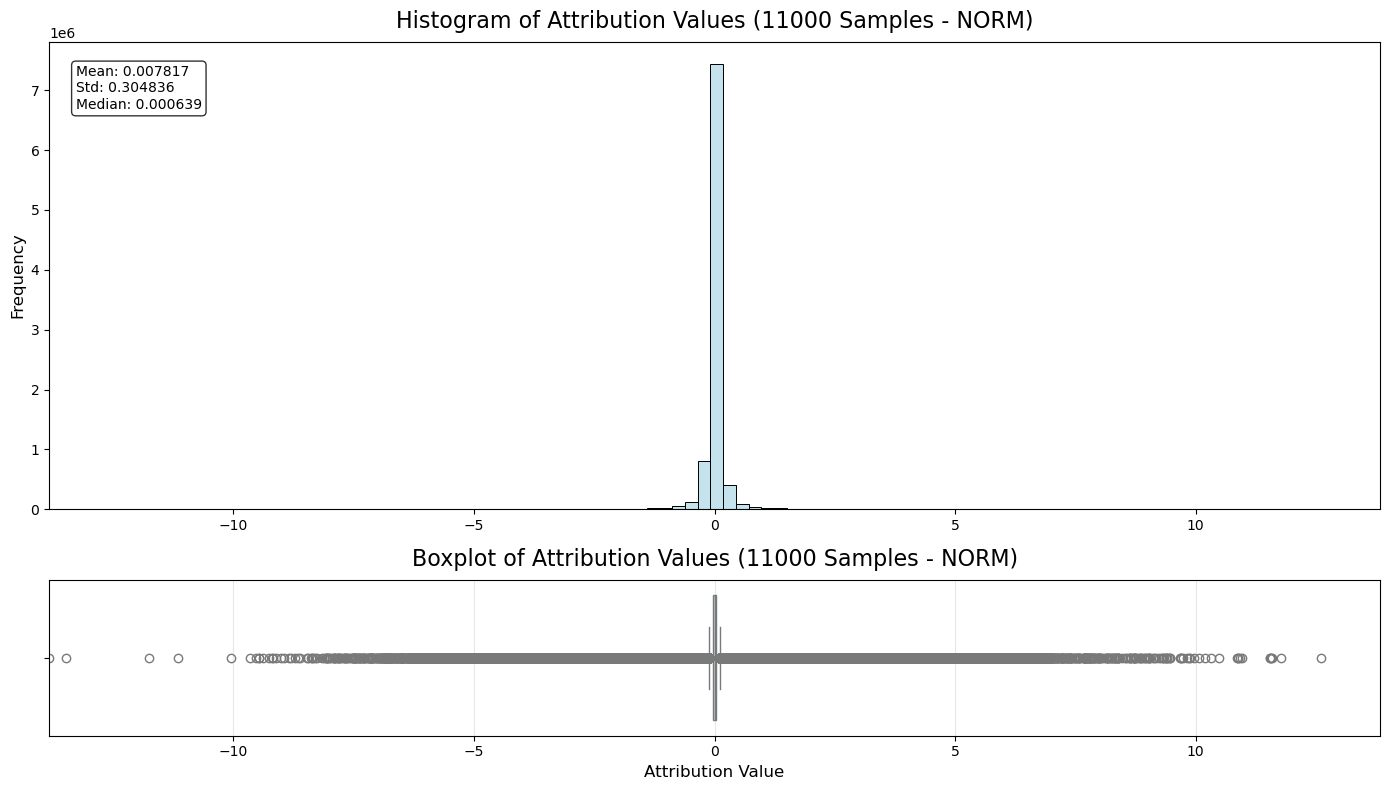

In [72]:
def plot_attribution_hist_and_box(flatten_attributions, label):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    ax_hist = axes[0]
    sns.histplot(flatten_attributions, bins=100, alpha=0.7, ax=ax_hist, color='lightblue')

    max_abs_value = max(abs(np.min(flatten_attributions)), abs(np.max(flatten_attributions)))
    ax_hist.set_xlim(-max_abs_value, max_abs_value)

    title_hist = f"Histogram of Attribution Values ({sample_size_to_observe} Samples - {label})"
    title_box = f"Boxplot of Attribution Values ({sample_size_to_observe} Samples - {label})"
    ax_hist.set_title(title_hist, fontsize=16, pad=10)
    ax_hist.set_ylabel('Frequency', fontsize=12)
    ax_hist.tick_params(axis='x', labelbottom=True)

    stats_text = f'Mean: {np.mean(flatten_attributions):.6f}\nStd: {np.std(flatten_attributions):.6f}\nMedian: {np.median(flatten_attributions):.6f}'
    ax_hist.text(0.02, 0.95, stats_text, transform=ax_hist.transAxes,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Boxplot
    ax_box = axes[1]
    sns.boxplot(x=flatten_attributions, color='lightblue', ax=ax_box)
    ax_box.set_title(title_box, fontsize=16, pad=10)
    ax_box.set_xlabel('Attribution Value', fontsize=12)
    ax_box.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Positiver Wert: Der Input hat einen positiven Einfluss auf die Entscheidung für die Zielklasse (z.B. spricht für MI)
# Negativer Wert: Der Input hat einen negativen Einfluss (spricht gegen die Zielklasse)
# Wert nahe 0: Der Input hat kaum Einfluss auf die Entscheidung.
plot_attribution_hist_and_box(attr_flat_NORM, "NORM")

Percentage of attributions with convergence delta between -0.25 and 0.25: 54.66%


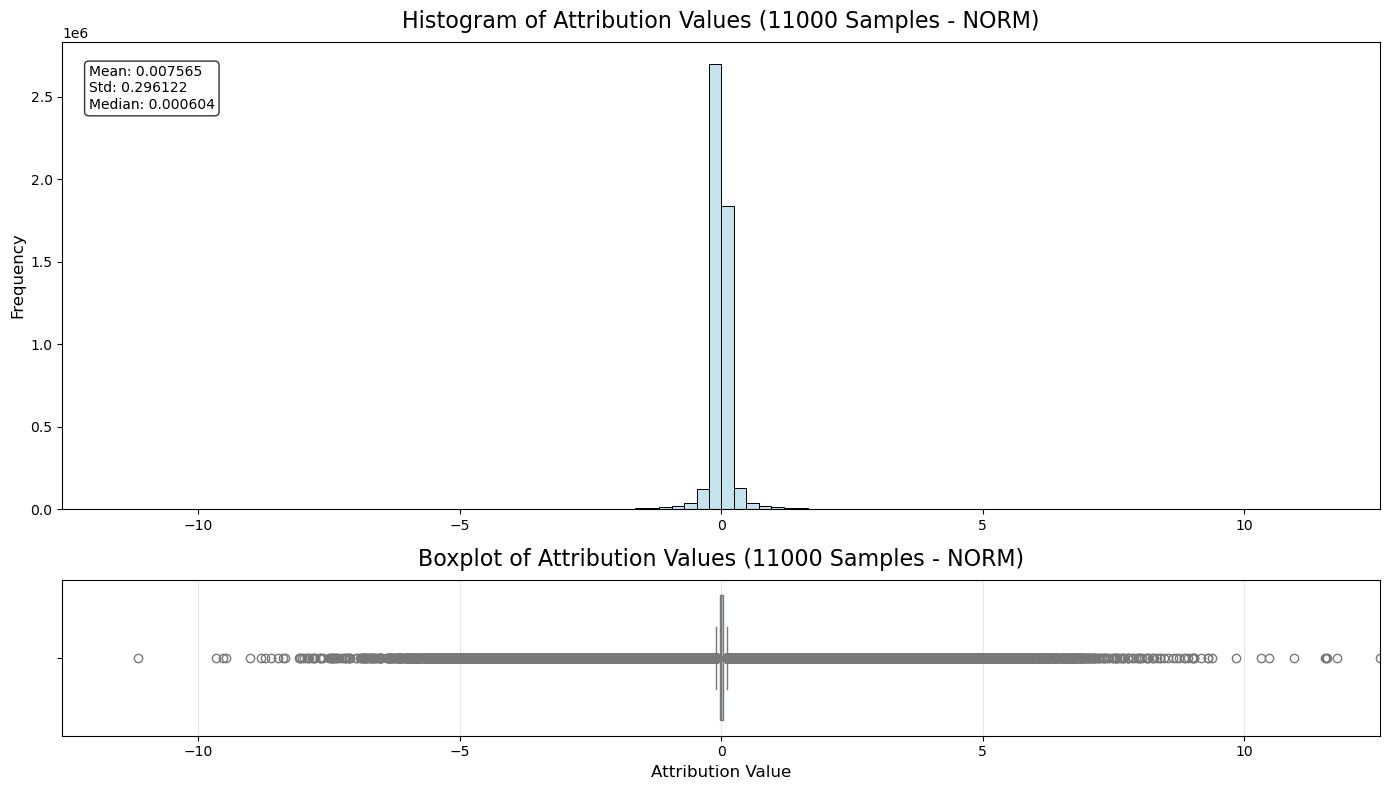

In [73]:
# filter attributionen, die ein delta zwischen -1 bis 1 haben
filtered_attributions_NORM = [attributions_NORM[i] for i in range(len(attributions_NORM)) if -0.25 <= convergence_deltas_NORM[i] <= 0.25]
# Flache Liste für Histogramm/Boxplot erzeugen
filtered_attr_flat_NORM = np.concatenate([attr.flatten() for attr in filtered_attributions_NORM])

# Wie viel Prozent fallen in filtered_attributions_NORM rein?
print(f"Percentage of attributions with convergence delta between -0.25 and 0.25: {len(filtered_attributions_NORM) / len(attributions_NORM) * 100:.2f}%")

plot_attribution_hist_and_box(filtered_attr_flat_NORM, "NORM")

In [74]:
# def plot_ecg_with_attributions(X, attributions, signal_idx=0, lead_names=None, sampling_frequency=100, fig_size=(15, 20)):
#     """
#     Plottet die 12 Ableitungen eines einzelnen EKG-Signals untereinander.

#     Args:
#         X: ECG-Daten, Shape [samples, time, leads] oder [samples, leads, time]
#         signal_idx: Index des zu plottenden Signals
#         lead_names: Liste der Lead-Namen (optional)
#         sampling_frequency: Sampling Rate (Hz)
#         fig_size: Größe der Figure
#     """
#     # Hole das Signal (Shape [time, leads] oder [leads, time])
#     signal = X[signal_idx]
#     # Transponiere falls nötig
#     if signal.shape[0] == len(lead_names):
#         signal = signal.T  # [time, leads]
#     if attributions.shape[0] == len(lead_names):
#         attributions = attributions.T  # [time, leads]

#     time_axis = np.arange(signal.shape[0]) / sampling_frequency

#     # Heatmap-Skala symmetrisch um 0
#     vmax_abs = max(abs(np.min(attributions)), abs(np.max(attributions)))
#     vmin = -vmax_abs
#     vmax = vmax_abs

#     fig, axes = plt.subplots(len(lead_names), 1, figsize=fig_size, sharex=True)
#     fig.suptitle(f'ECG Signal ({signal_idx}) with Attributions', fontsize=16, fontweight='bold', y=0.995)

#     scatter = None
#     for i in range(len(lead_names)):
#         axes[i].plot(time_axis, signal[:, i], color='grey', linewidth=1.2, alpha=0.95, label='ECG')
#         scatter = axes[i].scatter(time_axis, signal[:, i], c=attributions[:, i], cmap="RdBu_r",
#                                   s=80, alpha=0.95, vmin=vmin, vmax=vmax, edgecolors='none')
        
#         axes[i].set_ylabel(f'{lead_names[i]}', fontsize=11)
#         axes[i].grid(True, alpha=0.3)
#         axes[i].set_xlim(time_axis[0], time_axis[-1])
#         axes[i].set_xticks(np.linspace(time_axis[0], time_axis[-1], num=7))
#         axes[i].set_xticklabels([f"{t:.1f}" for t in np.linspace(time_axis[0], time_axis[-1], num=7)], fontsize=10)

#     axes[-1].set_xlabel('Time (s)', fontsize=12)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Platz für Colorbar lassen
#     cbar = fig.colorbar(scatter, ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, aspect=40, shrink=0.5)
#     cbar.set_label('Attribution Value', fontsize=12)
#     cbar.ax.xaxis.set_label_position('bottom')
#     plt.show()

# id = 0
# plot_ecg_with_attributions(X_test, attributions_NORM[id], signal_idx=id, lead_names=lead_names, sampling_frequency=SAMPLING_FREQUENCY)

In [75]:
# def plot_ecgs_with_attributions(X, attributions_list, sample_indices, lead_names=None, sampling_frequency=100, max_signals=100, figsize=(15, 18)):
#     """
#     Zeigt alle 12 Leads untereinander. In jedem Lead werden mehrere EKG-Signale übereinander gelegt,
#     und die Attributionen als Farbe angezeigt.
#     Args:
#         X: ECG-Daten, Shape [samples, time, leads] oder [samples, leads, time]
#         attributions_list: Liste von Attributionen, z.B. [samples][1, leads, time] oder [samples][1, time, leads]
#         sample_indices: Liste der Sample-Indizes, die geplottet werden sollen
#         lead_names: Liste der Lead-Namen (optional)
#         sampling_frequency: Sampling Rate (Hz)
#         max_signals: Maximale Anzahl der überlagerten Signale
#         figsize: Größe der Figure
#     """
#     # Shape check: [samples, time, leads] oder [samples, leads, time]
#     if X.shape[2] == len(lead_names):
#         time_axis = np.arange(X.shape[1]) / sampling_frequency
#         get_signal = lambda x, l: x[:, l]
#     elif X.shape[1] == len(lead_names):
#         time_axis = np.arange(X.shape[2]) / sampling_frequency
#         get_signal = lambda x, l: x[l, :]
#     else:
#         raise ValueError("X shape passt nicht zu den Erwartungen.")

#     fig, axes = plt.subplots(12, 1, figsize=figsize, sharex=True)
#     fig.suptitle(f"ECG-Signals with Attributions ({len(attributions_list)} Samples)", fontsize=16, fontweight='bold', y=0.995)

#     # Attributionen für Farbskala sammeln
#     all_attr = []
#     for i, idx in enumerate(sample_indices[:max_signals]):
#         attr = attributions_list[i][0]
#         # Falls [leads, time], transponieren zu [time, leads]
#         if attr.shape[0] == len(lead_names):
#             attr = attr.T
#         all_attr.append(attr)
        
#     all_attr = np.array(all_attr)
#     vmax_abs = np.max(np.abs(all_attr))
#     vmin, vmax = -vmax_abs, vmax_abs

#     for lead_idx in range(12):

#         ax = axes[lead_idx]
#         for i, idx in enumerate(sample_indices[:max_signals]):
#             signal = get_signal(X[idx], lead_idx)  # [time]
#             attr = attributions_list[i][0]
#             if attr.shape[0] == len(lead_names):
#                 attr = attr.T
#             attr_lead = attr[:, lead_idx]  # [time]
#             ax.plot(time_axis, signal, color='grey', alpha=0.15)
#             sc = ax.scatter(time_axis, signal, c=attr_lead, cmap='RdBu_r', s=80, vmin=vmin, vmax=vmax, edgecolors='none', alpha=0.95)
        
#         ax.set_ylabel(f"{lead_names[lead_idx]}", fontsize=10)
#         ax.grid(True, alpha=0.3)
#         ax.set_xlim(time_axis[0], time_axis[-1])
#         ax.set_xticks(np.linspace(time_axis[0], time_axis[-1], num=7))
#         ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(time_axis[0], time_axis[-1], num=7)], fontsize=9)

#     axes[-1].set_xlabel('Time (s)', fontsize=12)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Platz für Colorbar lassen
#     cbar = fig.colorbar(sc, ax=axes, orientation='horizontal', fraction=0.04, pad=0.03, aspect=40, shrink=0.5)
#     cbar.set_label('Attribution Value', fontsize=12)
#     cbar.ax.xaxis.set_label_position('bottom')
    
#     plt.show()

# plot_ecgs_with_attributions(X_test, attributions_NORM, sample_indices_NORM, lead_names=lead_names, max_signals=100, figsize=(15, 20))

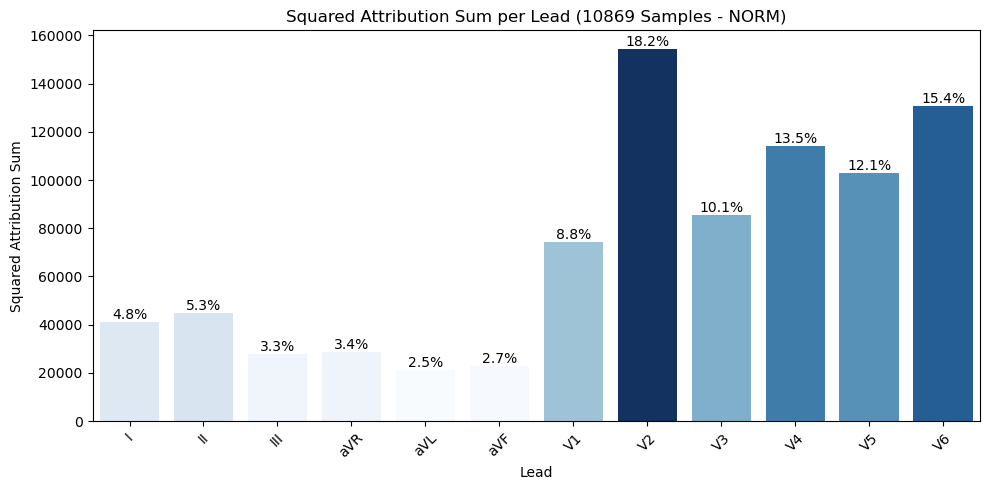

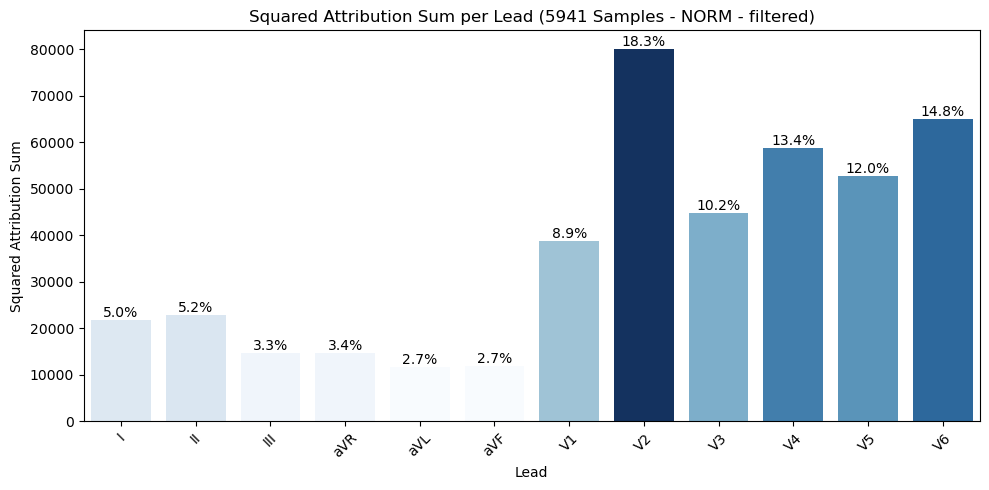

In [76]:
def plot_leadwise_attribution_sum(attributions, lead_names, class_name="X"):
    """
    Plottet die Summe der Attributionen pro Ableitung (Lead) als Balkendiagramm.
    Args:
        attributions: Liste von Attributionen, z.B. [samples][1, leads, time] oder [samples][1, time, leads]
        lead_names: Liste der Lead-Namen
    """
    # Attributionen zu [samples, time, leads] bringen
    attr_arr = []
    for attr in attributions:
        a = attr[0]
        if a.shape[0] == len(lead_names):
            a = a.T  # [time, leads]
        attr_arr.append(a)
    attr_arr = np.array(attr_arr)  # [samples, time, leads]

    # Summe pro Lead über alle Samples und Zeitpunkte
    lead_sums = np.sum(attr_arr, axis=(0, 1))  # [leads]
    lead_squared_sums = np.sum(attr_arr ** 2, axis=(0, 1))  # [leads]

    # Prozentuale Verteilung (bezogen auf die Summe aller Leads)
    percent = 100 * lead_squared_sums / np.sum(lead_squared_sums)

    # DataFrame für hue-Farbe
    import pandas as pd
    df = pd.DataFrame({'Lead': lead_names, 'Value': lead_squared_sums})

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df, x='Lead', y='Value', hue='Value', palette='Blues', dodge=False, legend=False)
    plt.title(f"Squared Attribution Sum per Lead ({len(attributions)} Samples - {class_name})")
    plt.ylabel("Squared Attribution Sum")
    plt.xlabel("Lead")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Prozentwerte über die Balken schreiben
    for i, p in enumerate(percent):
        ax.text(i, lead_squared_sums[i], f"{p:.1f}%", ha='center', va='bottom', fontsize=10)

    plt.show()

plot_leadwise_attribution_sum(attributions_NORM, lead_names, "NORM")

plot_leadwise_attribution_sum(filtered_attributions_NORM, lead_names, "NORM - filtered")

## Label: MI

In [29]:
sample_indices_MI, target_idx_MI = grab_samples(y_test, "MI", sample_size_to_observe)
attributions_MI, convergence_deltas_MI = compute_integrated_gradients_for_label(model, X_test, sample_indices_MI, target_idx_MI)

Zufällig verarbeitete MI-Samples: 6769 von 6769 (max)


Computing attributions for target 0: 100%|██████████| 6769/6769 [09:58<00:00, 11.31it/s]


In [ ]:
save_attributions(attributions_MI, sample_indices_MI, convergence_deltas_MI, "MI")

In [56]:
attributions_MI, sample_indices_MI, convergence_deltas_MI = load_attributions("MI")

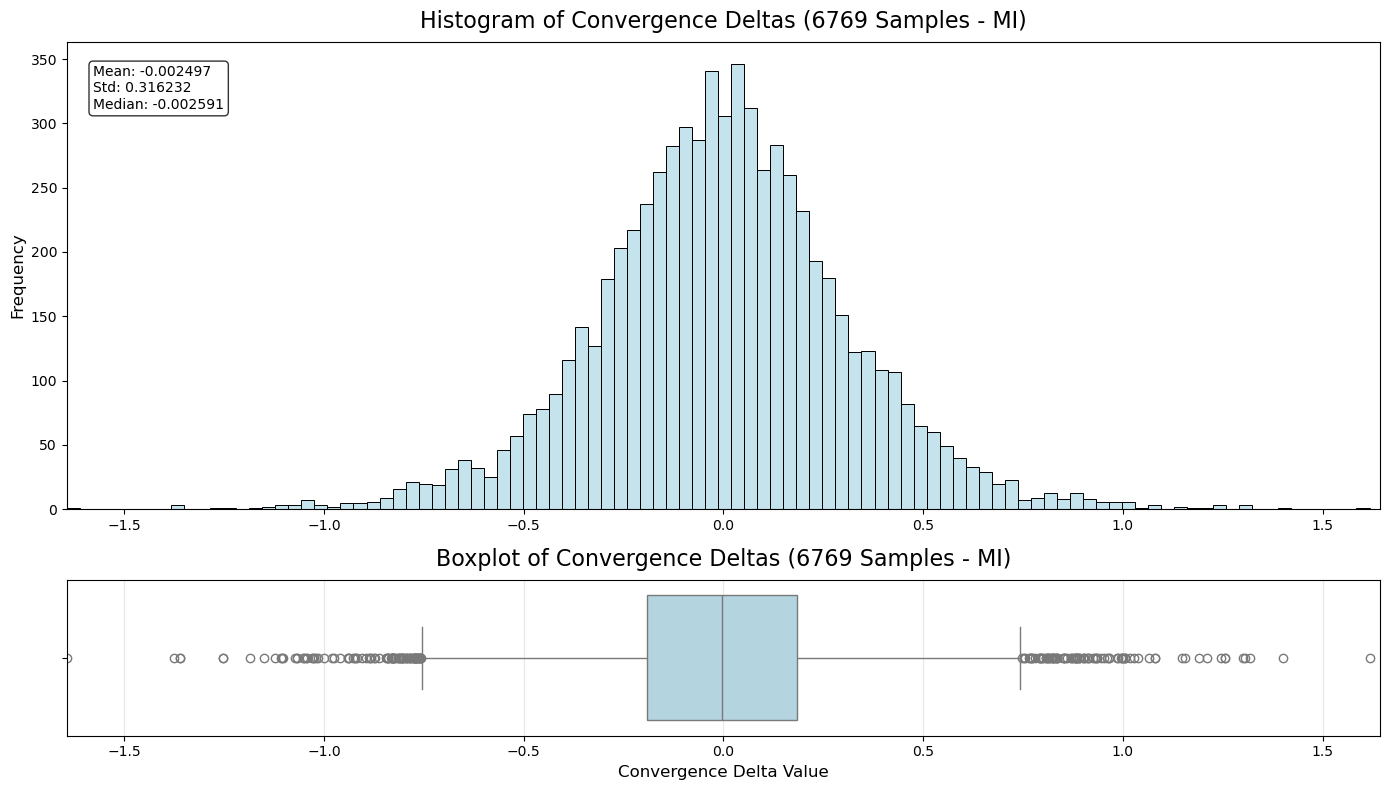

In [58]:
# convergence_delta ist ein Wert, der misst, wie gut die Integrated Gradients die Completeness-Eigenschaft erfüllen:
# Die Summe der Attributionen sollte möglichst genau der Differenz zwischen Modell-Output für das echte Sample und
# die Baseline entsprechen (f(x) - f(baseline)).

# Typische Anwendungen:
# Qualitätskontrolle: Ein kleiner Wert zeigt, dass die Attributionen zuverlässig sind. Ein großer Wert kann auf Probleme
#   (z.B. Modellinstabilität, ungeeignete Baseline) hinweisen.
# Debugging: Du kannst convergence_delta für jedes Sample ausgeben, plotten oder als Filter verwenden (z.B. nur Attributionen
#   mit kleinem delta weiter analysieren).

# Kleine Werte (nahe 0): Die Attributionen sind zuverlässig und erfüllen die Completeness-Eigenschaft gut.
# Große Werte: Die Attributionen sind weniger zuverlässig. Mögliche Ursachen: Modellinstabilität, ungeeignete Baseline, numerische Probleme.

plot_convergence_delta_hist_and_box(convergence_deltas_MI, "MI")

In [59]:
attr_flat_MI = attribution_statistics(attributions_MI)

=== ATTRIBUTION ANALYSIS ===
Samples: 6769
Total attribution values per sample: 5685960 (Samples*Leads*Sequence Length)
Min: -14.289715 (less influence)
Max: 14.909438 (most influence)
Mean: 0.006130
Std: 0.292315

Proportion of values that have almost no, positive, or negative 
influence on the decision for the target class.
Neutral (-0.1 < x < 0.1): 4454323 (78.3%)
Positive (x > 0.1): 624073 (11.0%)
Negative (x < -0.1): 607564 (10.7%)


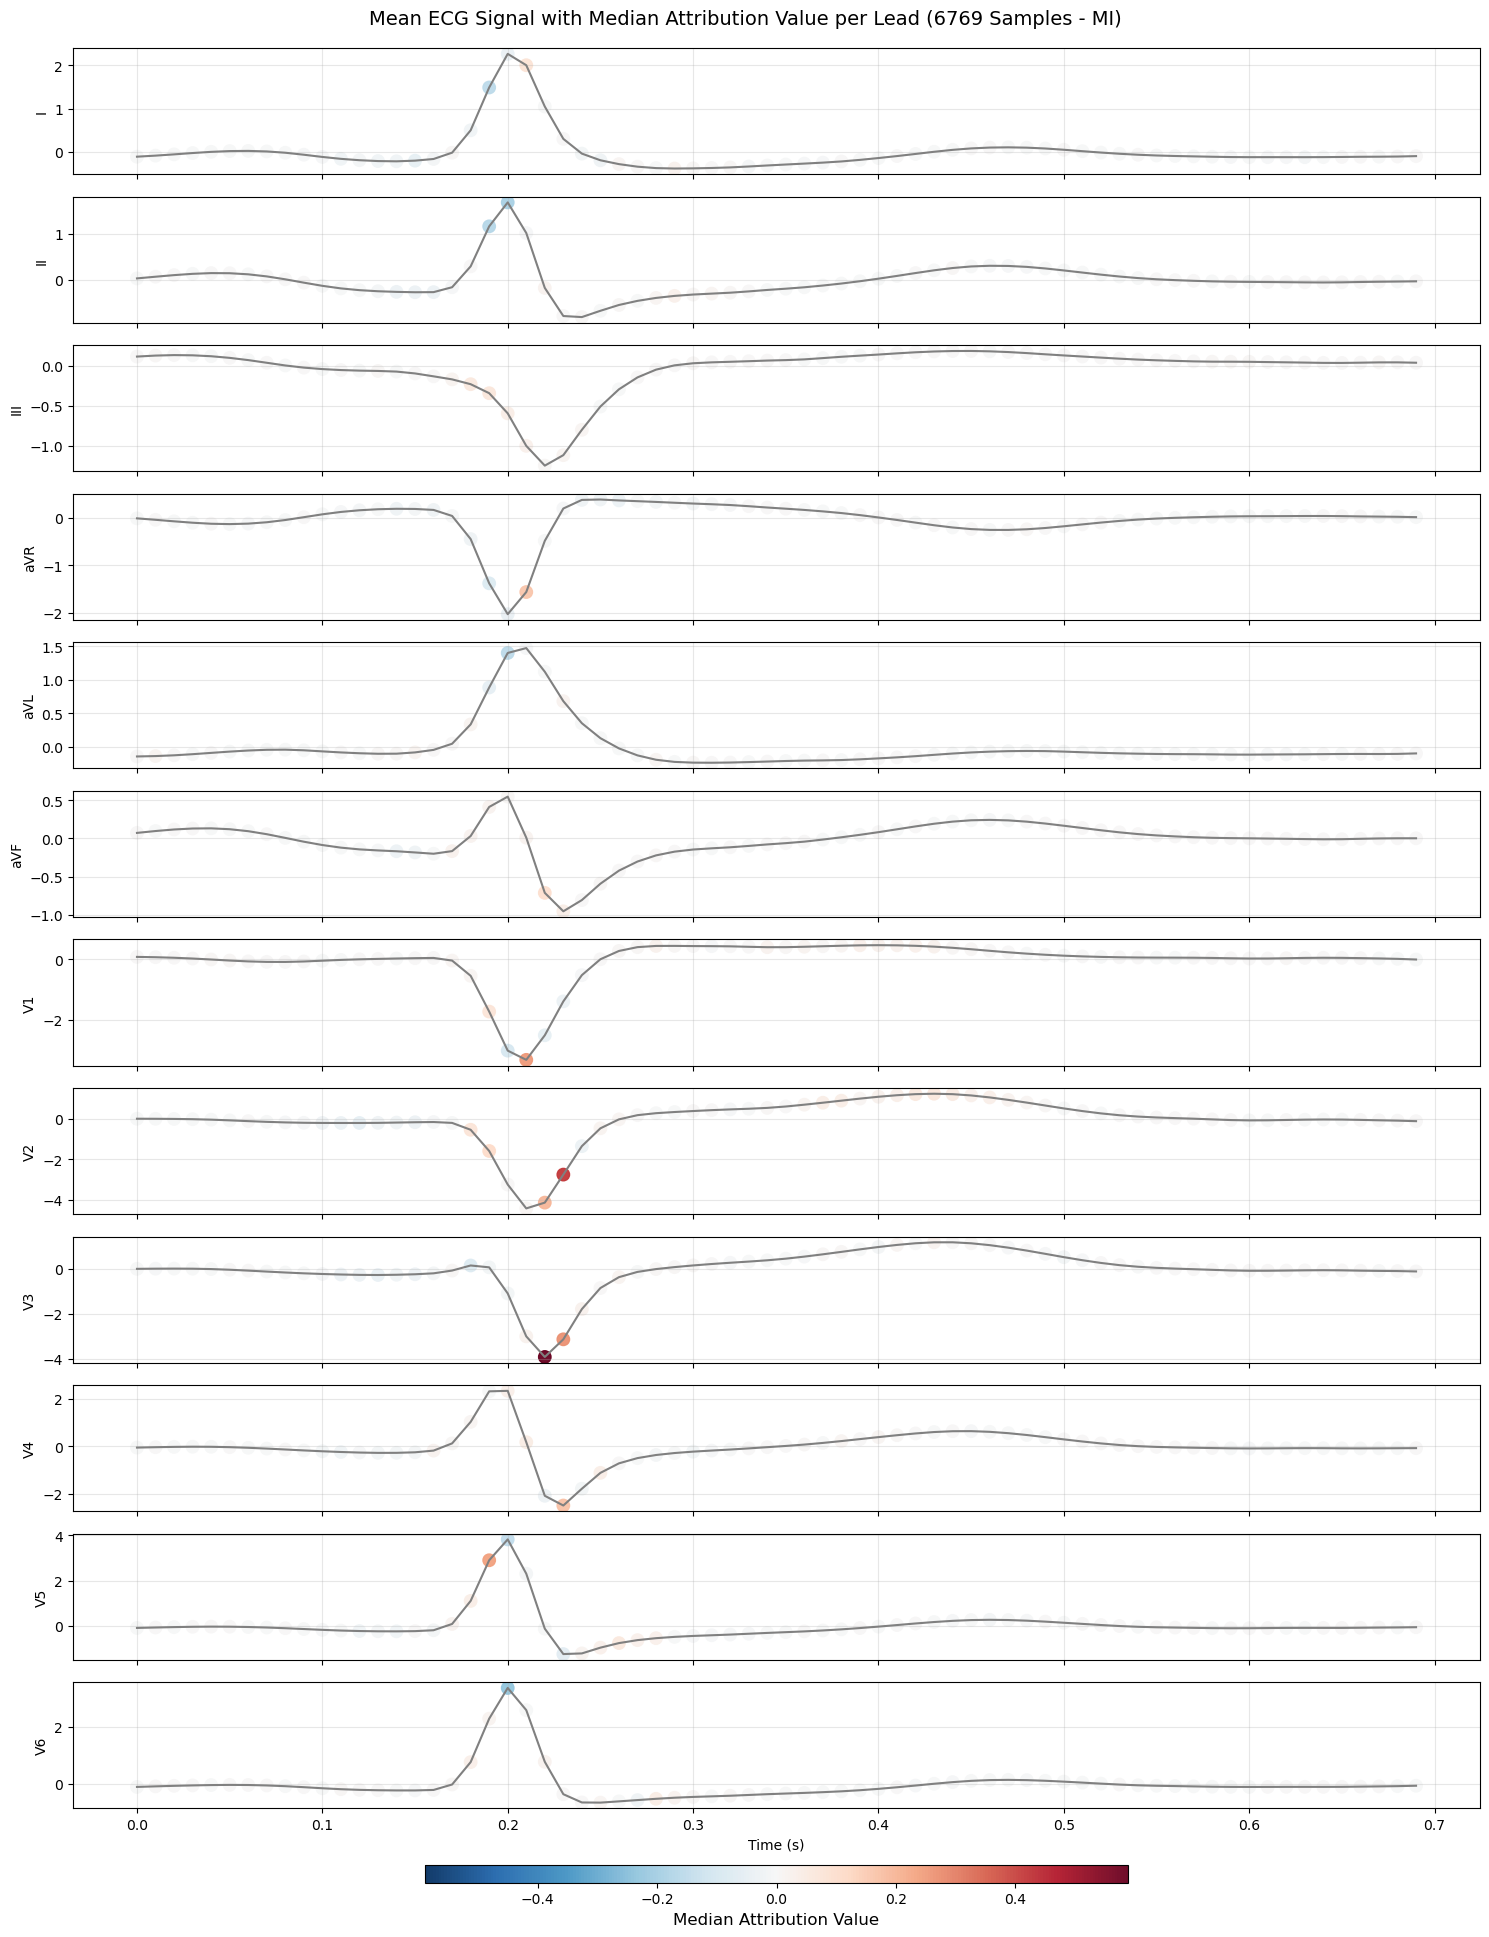

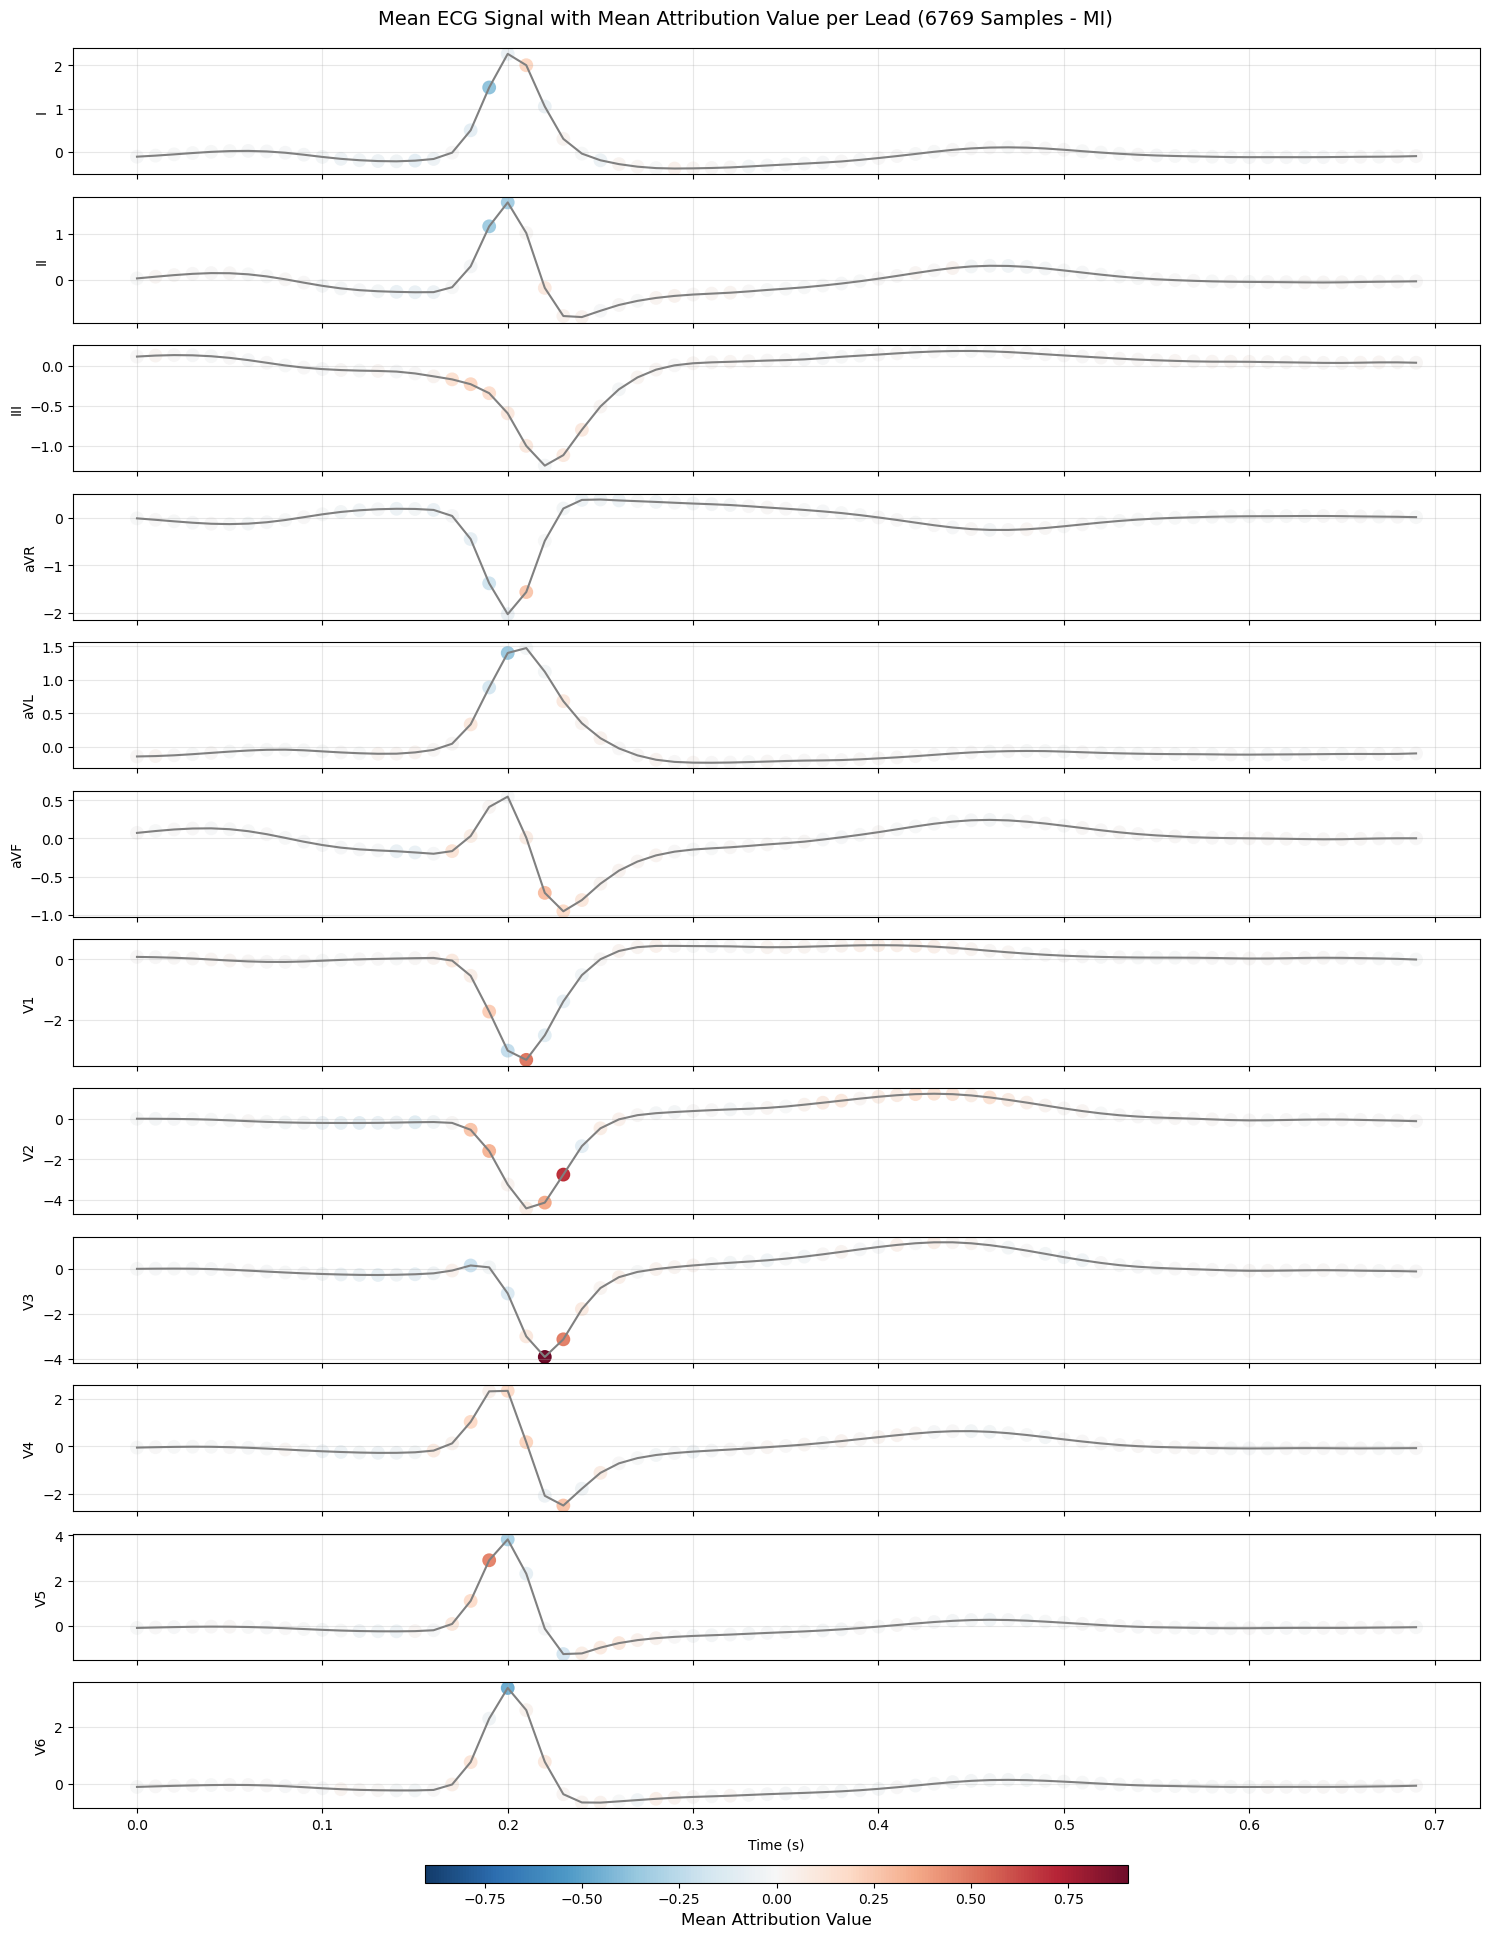

In [60]:
plot_ecg_attributions_summary(
    attributions_MI, X_test, sample_indices_MI, lead_names,
    SAMPLING_FREQUENCY, 'median', "MI")

plot_ecg_attributions_summary(
    attributions_MI, X_test, sample_indices_MI, lead_names,
    SAMPLING_FREQUENCY, 'mean', "MI")

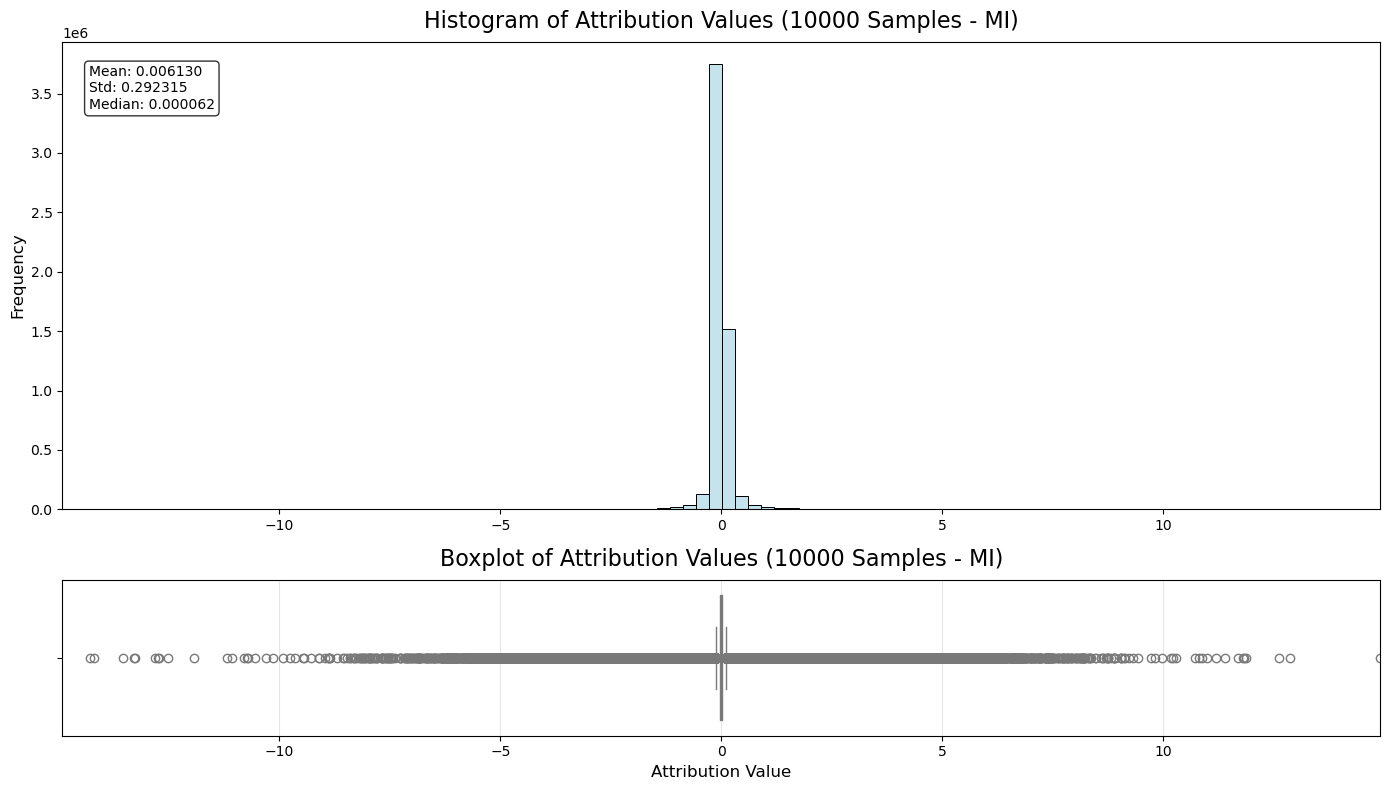

In [61]:
plot_attribution_hist_and_box(attr_flat_MI, "MI")

Percentage of attributions with convergence delta between -0.25 and 0.25: 61.74%


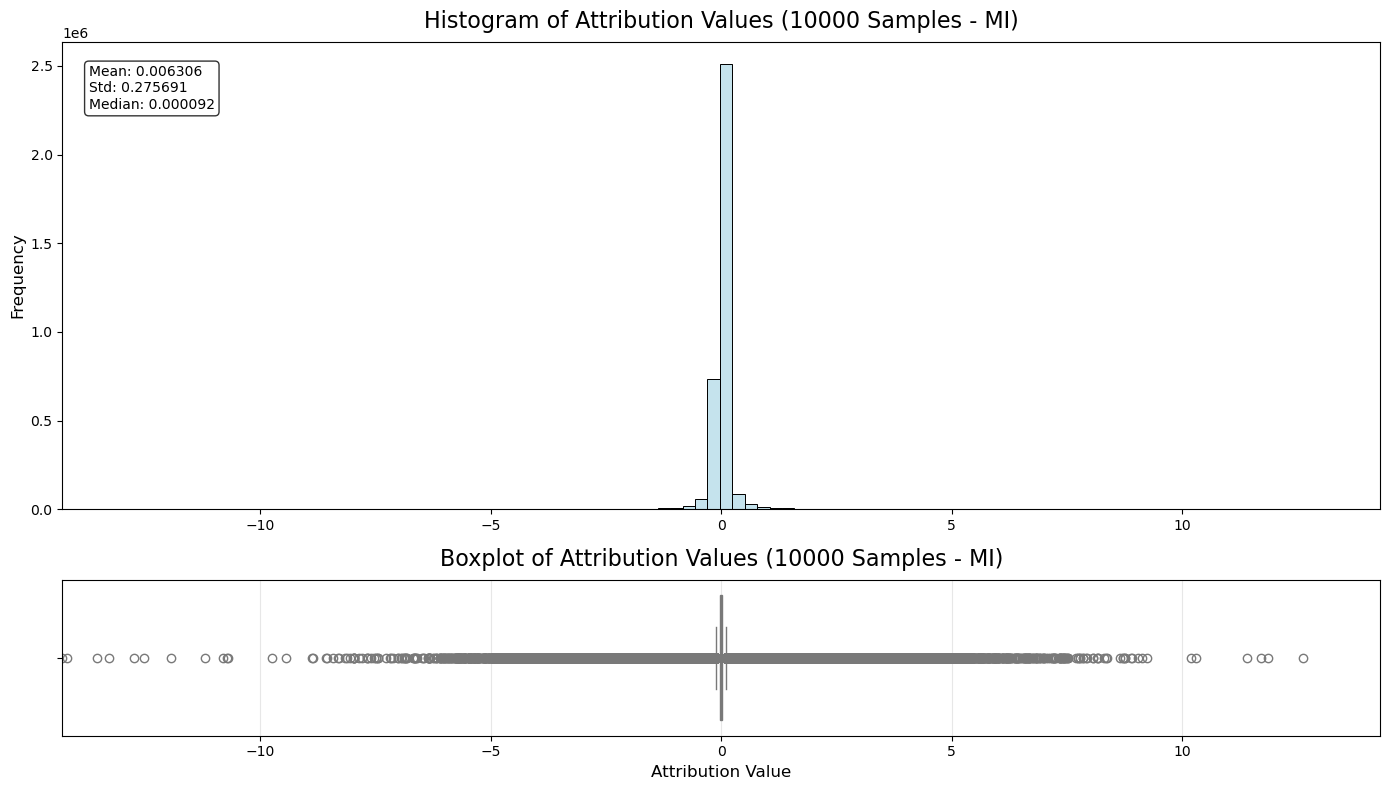

In [62]:
# filter attributions
filtered_attributions_MI = [attributions_MI[i] for i in range(len(attributions_MI)) if -0.25 <= convergence_deltas_MI[i] <= 0.25]
filtered_attr_flat_MI = np.concatenate([attr.flatten() for attr in filtered_attributions_MI])

# Wie viel Prozent fallen in filtered_attributions_MI rein?
print(f"Percentage of attributions with convergence delta between -0.25 and 0.25: {len(filtered_attributions_MI) / len(attributions_MI) * 100:.2f}%")

plot_attribution_hist_and_box(filtered_attr_flat_MI, "MI")

In [ ]:
# id = 3
# plot_ecg_with_attributions(X_test, attributions_MI[id], signal_idx=sample_indices_MI[id], lead_names=lead_names)

In [ ]:
# plot_ecgs_with_attributions(X_test, attributions_MI, sample_indices_MI, lead_names, max_signals=sample_size_to_observe, figsize=(15, 20))

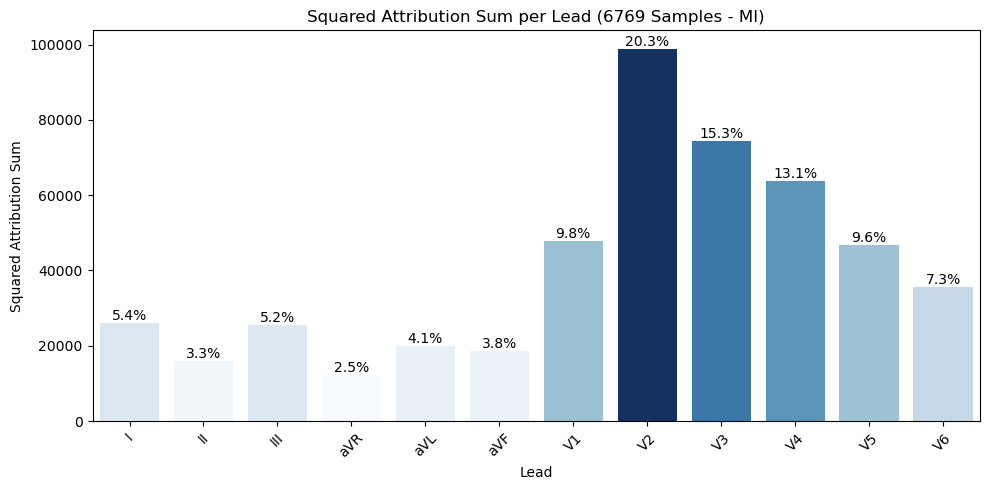

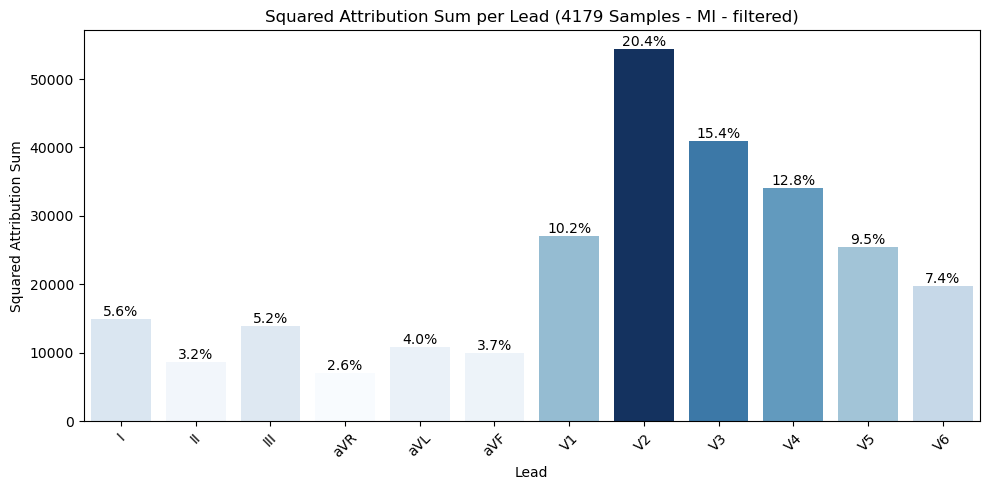

In [64]:
plot_leadwise_attribution_sum(attributions_MI, lead_names, "MI")
plot_leadwise_attribution_sum(filtered_attributions_MI, lead_names, "MI - filtered")